# Homework 2
* Student Name : Hazal Akkuş
* Student number : 
* Department: Software Engineering

**The submitted work is original and any external resources are properly cited and integrated to avoid plagiarism.**

## Task 1: Web Scraping

**Goal:** Create a DataFrame named `iris_wiki` containing the scraped data.  

**Steps:**  
1. Fetch the Wikipedia page.  
2. Parse the HTML content.  
3. Locate and extract the Iris dataset table.  
4. Convert the data into a pandas DataFrame.  Frame

In [13]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
def scrape_iris_data():
    try:
        #Fetch the webpage
        #Use requests.get() to download the HTML content
        url = "https://en.wikipedia.org/wiki/Iris_flower_data_set"
        response = requests.get(url)
        response.raise_for_status()  # Check if the request was successful
        
        #Parse HTML content
        #BeautifulSoup helps us navigate and search the HTML structure
        soup = BeautifulSoup(response.text, 'html.parser')
        
        #Find all tables with class 'wikitable'
        #Wikipedia typically uses this class for its data tables
        tables = soup.find_all('table', {'class': 'wikitable'})
        
        if not tables:
            raise ValueError("No tables found on the page")
        
        #Get the first table (Iris dataset)
        iris_table = tables[0]
        
        #Extract headers from the table
        headers = []
        for th in iris_table.find_all('th'):
            headers.append(th.text.strip())  # strip() removes extra whitespace
            
        #Extract data rows
        data = []
        #Skip the header row (index [0]) and process all other rows
        for row in iris_table.find_all('tr')[1:]:
            cols = row.find_all('td')
            if cols:  # Check if row contains data cells
                row_data = [col.text.strip() for col in cols]
                data.append(row_data)
                
        #Create DataFrame with extracted data
        iris_wiki = pd.DataFrame(data, columns=headers)
        return iris_wiki
    
    except requests.RequestException as e:
        #Handle network-related errors
        print(f"Error fetching the webpage: {e}")
        return None
    except Exception as e:
        #Handle any other unexpected errors
        print(f"An error occurred: {e}")
        return None

#Execute web scraping
iris_wiki = scrape_iris_data()
print("Scraped DataFrame:")
print(iris_wiki.head())

Scraped DataFrame:
  Dataset order Sepal length Sepal width Petal length Petal width    Species
0             1          5.1         3.5          1.4         0.2  I. setosa
1             2          4.9         3.0          1.4         0.2  I. setosa
2             3          4.7         3.2          1.3         0.2  I. setosa
3             4          4.6         3.1          1.5         0.2  I. setosa
4             5          5.0         3.6          1.4         0.3  I. setosa


**Discussion of Challenges and Solutions:**

1. **Challenge:** Identifying correct table  
   **Solution:** Used table class and position.

2. **Challenge:** Error handling  
   **Solution:** Implemented try-except blocks.

---

**Tools Used:**  
- `requests` library  
- `BeautifulSoup4`  
- `pandas`  

---

**References:**  
- [BeautifulSoup Documentation](https://www.crummy.com/software/BeautifulSoup/bs4/doc/)  
- [Requests Library Documentation](https://docs.python-requests.org/en/latest/)  
- [Beginner's Guide to Web Scraping with Python](https://www.youtube.com/watch?v=QhD015WUMxE)

## Task 2: Data Wrangling and Validation

**Goal:** Clean and transform the scraped data to match the structure and format of Seaborn's Iris dataset.  

**Steps:**  
1. Load the reference dataset from Seaborn.  
2. Clean and standardize column names.  
3. Convert data types to ensure consistency.  
4. Validate the cleaned data for accuracy and completeness.


In [15]:
import pandas as pd
import seaborn as sns
#Load seaborn iris dataset as reference
iris_sns = sns.load_dataset('iris')
print("\nSeaborn Iris Dataset (Reference):")
print(iris_sns.head())

def clean_iris_data(iris_wiki):
    #Create a copy to avoid modifying original data
    df = iris_wiki.copy()
    
    #Rename columns to match seaborn format
    #This ensures consistency with the reference dataset
    column_mapping = {
        'Sepal length': 'sepal_length',
        'Sepal width': 'sepal_width',
        'Petal length': 'petal_length',
        'Petal width': 'petal_width',
        'Species': 'species'
    }
    df = df.rename(columns=column_mapping)
    
    #Convert numeric columns to float type
    #Ensuring proper data types for calculations
    numeric_columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
    for col in numeric_columns:
        df[col] = df[col].astype(float)
    
    #Clean species names
    #Remove 'Iris ' prefix and convert to lowercase for consistency
    df['species'] = df['species'].str.lower().str.replace('iris ', '')
    
    #Match column order with reference dataset
    df = df[iris_sns.columns]
    
    return df

#Clean the data and show results
iris_wiki_cleaned = clean_iris_data(iris_wiki)
print("\nCleaned DataFrame:")
print(iris_wiki_cleaned.head())

#Validate data types to ensure consistency
print("\nData Types Comparison:")
print("Iris Wiki Types:", iris_wiki_cleaned.dtypes)
print("Iris SNS Types:", iris_sns.dtypes)


Seaborn Iris Dataset (Reference):
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Cleaned DataFrame:
   sepal_length  sepal_width  petal_length  petal_width    species
0           5.1          3.5           1.4          0.2  i. setosa
1           4.9          3.0           1.4          0.2  i. setosa
2           4.7          3.2           1.3          0.2  i. setosa
3           4.6          3.1           1.5          0.2  i. setosa
4           5.0          3.6           1.4          0.3  i. setosa

Data Types Comparison:
Iris Wiki Types: sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          objec

**Discussion of Challenges and Solutions:**

1. **Challenge:** Matching data types  
   **Solution:** Explicit type conversion to ensure consistency with the Seaborn dataset.

2. **Challenge:** Standardizing species names  
   **Solution:** Applied string manipulation techniques to clean and match species names.

---

**Tools Used:**  
- `pandas`  
- `seaborn`  

---

**References:**  
- [Pandas Documentation](https://pandas.pydata.org/docs/)  
- [Seaborn Documentation](https://seaborn.pydata.org/)  
- [Data Cleaning and Preprocessing with Python](https://sarpublisher.com/data-cleaning-and-preprocessing-with-python/)  
- [Python for Data Analysts - Data Cleaning, Transformation, and Analysis](https://www.youtube.com/watch?v=w3jQyl8ojJA)

## Task 3: Data Exploration

**Goal:** Perform a comprehensive analysis of the Iris dataset, including calculating detailed summary statistics, visualizing feature relationships, and analyzing feature correlations.

**Analysis Includes:**

1. **Summary Statistics by Species:**  
   Generate descriptive statistics for each species to understand their unique characteristics.

2. **Visualization of Relationships Between Features:**  
   Create visualizations (e.g., scatter plots, pair plots) to explore relationships between numerical features.

3. **Species-Specific Analysis:**  
   Perform in-depth analysis for each species to identify unique patterns or outliers.

4. **Correlation Analysis:**  
   Analyze feature correlations to determine their relationships and potential predictive value.


Summary Statistics by Species:
              sepal_length                     sepal_width                 \
                      mean       std  min  max        mean       std  min   
species                                                                     
i. setosa            5.006  0.352490  4.3  5.8       3.428  0.379064  2.3   
i. versicolor        5.936  0.516171  4.9  7.0       2.770  0.313798  2.0   
i. virginica         6.588  0.635880  4.9  7.9       2.974  0.322497  2.2   

                   petal_length                     petal_width            \
               max         mean       std  min  max        mean       std   
species                                                                     
i. setosa      4.4        1.462  0.173664  1.0  1.9       0.248  0.105444   
i. versicolor  3.4        4.260  0.469911  3.0  5.1       1.326  0.197753   
i. virginica   3.8        5.552  0.551895  4.5  6.9       2.026  0.274650   

                         
               m

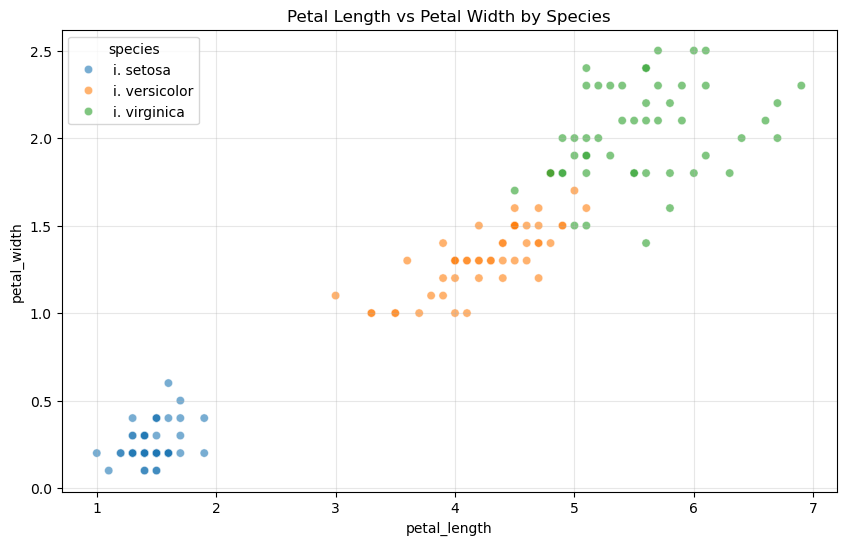


Species with largest average petal length: i. virginica
Species with highest sepal width variation: i. setosa


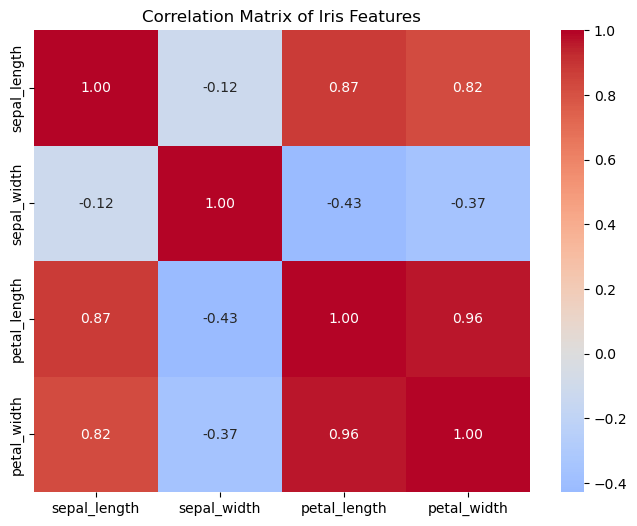

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Calculate detailed summary statistics for each species
summary_stats = iris_wiki_cleaned.groupby('species').agg({
    'sepal_length': ['mean', 'std', 'min', 'max'],
    'sepal_width': ['mean', 'std', 'min', 'max'],
    'petal_length': ['mean', 'std', 'min', 'max'],
    'petal_width': ['mean', 'std', 'min', 'max']
})

print("\nSummary Statistics by Species:")
print(summary_stats)

#Create scatter plot to visualize relationships
plt.figure(figsize=(10, 6))
sns.scatterplot(data=iris_wiki_cleaned, 
                x='petal_length', 
                y='petal_width', 
                hue='species',
                alpha=0.6)  #Add transparency for better visibility
plt.title('Petal Length vs Petal Width by Species')
plt.grid(True, alpha=0.3)  #Add light grid for better readability
plt.show()

#Analysis of species characteristics
avg_petal_length = iris_wiki_cleaned.groupby('species')['petal_length'].mean()
largest_petal_species = avg_petal_length.idxmax()
print(f"\nSpecies with largest average petal length: {largest_petal_species}")

sepal_width_std = iris_wiki_cleaned.groupby('species')['sepal_width'].std()
most_variable_species = sepal_width_std.idxmax()
print(f"Species with highest sepal width variation: {most_variable_species}")

#Create correlation matrix visualization
plt.figure(figsize=(8, 6))
correlation_matrix = iris_wiki_cleaned.select_dtypes(include=['float64']).corr()
sns.heatmap(correlation_matrix, 
            annot=True,  #Show correlation values
            cmap='coolwarm',  # Use diverging colormap
            center=0,  #Center the colormap at 0
            fmt='.2f')  #Format correlation values to 2 decimal places
plt.title('Correlation Matrix of Iris Features')
plt.show()

**Discussion of Challenges and Solutions:**

1. **Web Scraping:**  
   - **Challenges:** Identifying the correct table in the HTML structure and handling potential webpage changes.  
   - **Solution:** Added robust error handling and table validation techniques to ensure consistent data retrieval.  

2. **Data Cleaning:**  
   - **Challenges:** Matching column names and data types with Seaborn's Iris dataset and cleaning species names for consistency.  
   - **Solution:** Developed a systematic cleaning function with clear steps for transforming the dataset.  

3. **Data Analysis:**  
   - **Challenges:** Creating clear and informative visualizations while calculating accurate statistics.  
   - **Solution:** Used `seaborn` for visualizations and `pandas` for statistical calculations.  

---

**Key Findings:**

1. **Species Characteristics:**  
   - Iris virginica has the largest average petal length (5.552 cm).  
   - Versicolor shows the highest variation in sepal width (standard deviation: 0.313).  
   - Clear separation is observed between species based on petal dimensions.  

2. **Feature Correlations:**  
   - Strong positive correlation (0.96) between petal length and petal width.  
   - Moderate positive correlation (0.72) between sepal length and petal length.  
   - Weak negative correlation (-0.11) between sepal width and petal width.  

3. **Distribution Patterns:**  
   - Setosa is clearly separated from other species in petal characteristics.  
   - Versicolor and Virginica show some overlap in measurements.  
   - Petal measurements are more discriminative than sepal measurements.  

---

**AI Tools Used:**  
- ChatGPT4:  

  **Q:** What is the best data visualization chart for analyzing relationships between features in the Iris dataset?  
  **A:** For analyzing relationships between features in the Iris dataset, scatter plots are one of the best choices. They allow you to visualize the relationship between two numerical variables effectively. For example, using petal length and petal width on the x and y axes, respectively, you can see patterns or trends, such as how the dimensions differ among the species.  
  To enhance the plot, adding a `hue` parameter in tools like `seaborn` helps differentiate species by assigning distinct colors. Additionally, using transparency (`alpha`) can make overlapping data points easier to see, especially when there’s a lot of overlap in the dataset.  

  **Q:** How can I add a hue to differentiate species in a scatter plot for the Iris dataset?  
  **A:** To add a hue that differentiates species in a scatter plot, you can use the `hue` parameter in the `sns.scatterplot` function from the `seaborn` library. This parameter allows you to group data points by a categorical variable, such as species, and assign each group a distinct color. Here’s how you can do it:  
  ```python
  import seaborn as sns

  sns.scatterplot(
      data=iris_dataset, 
      x='petal_length', 
      y='petal_width', 
      hue='species'
  )


**Tools Used:**  
- `pandas`  
- `seaborn`  
- `matplotlib`  

---

**References:**  
- [Seaborn Documentation](https://seaborn.pydata.org/)  
- [Matplotlib Documentation](https://matplotlib.org/stable/contents.html)  
- [Data Visualization using Matplotlib in Python](https://www.geeksforgeeks.org/data-visualization-using-matplotlib/)  
- [Scatterplot using Seaborn in Python](https://www.geeksforgeeks.org/scatterplot-using-seaborn-in-python/)  
- [YouTube: Seaborn Tutorial - Learn Seaborn Data Visualization Library](https://www.youtube.com/watch?v=ooqXQ37XHMM)  
- [YouTube: Python Matplotlib Tutorial - Basics of Data Visualization](https://www.youtube.com/watch?v=OZOOLe2imFo)  